In [17]:
import functools as ft
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy.signal import correlate, find_peaks

from simulator.utils.plots import *
from simulator.utils.quat import quat_to_euler

experiment_name = 'square_20251017'
run = 1

h5_dir = os.path.join('..', 'data','real', 'raw', 'rosbags')
bag_name = f'rosbag2_{experiment_name}_run{run}'
h5_path = os.path.join(h5_dir, f'{bag_name}.h5')

### Load HDF5 bag files

In [18]:
dfs = dict()

with pd.HDFStore(h5_path, 'r') as store:
    for key in store.keys():
        df = pd.read_hdf(h5_path, key=key)
        dfs[key] = df

### Extract data from individual topics

In [19]:
def extract_cols(df, cols, prefix=[]):
    if isinstance(cols, list):
        cols = dict(zip(cols, cols))
        
    cols = {
        '.'.join(prefix + [old]): new for old, new in cols.items()
    }
    
    return df[cols.keys()].rename(columns=cols)

def extract_position(df, prefix=[]):
    return extract_cols(df, ['x', 'y', 'z'], prefix)

def extract_orientation(df, prefix=[]):
    df = extract_cols(df, {'x': 'qx', 'y': 'qy', 'z': 'qz', 'w': 'qw'}, prefix)

    quats = df.values # shape (T, 4)
    euler_angles = jax.vmap(quat_to_euler)(quats)  # shape (T, 3)
    yaw, pitch, roll = euler_angles.T
    df['yaw'] = np.asarray(yaw)
    df['pitch'] = np.asarray(pitch)
    df['roll'] = np.asarray(roll)
    
    return df

def extract_pose(df, prefix=[]):
    return pd.concat([
        extract_position(df, prefix=prefix + ['position']),
        extract_orientation(df, prefix=prefix + ['orientation']),
    ], axis=1)
    
def extract_lin_vel(df, prefix=[]):
    return extract_cols(df, {'x': 'vx', 'y': 'vy', 'z': 'vz'}, prefix)

def extract_ang_vel(df, prefix=[]):
    return extract_cols(df, {'x': 'wx', 'y': 'wy', 'z': 'wz'}, prefix)

def extract_twist(df, prefix=[]):
    return pd.concat([
        extract_lin_vel(df, prefix=prefix + ['linear']),
        extract_ang_vel(df, prefix=prefix + ['angular']),
    ], axis=1)

def extract_odom(df, prefix=[]):
    return pd.concat([
        extract_pose(df, prefix=prefix + ['pose.pose']),
        extract_twist(df, prefix=prefix + ['twist.twist']),
    ], axis=1)

def extract_lin_accel(df, prefix=[]):
    return extract_cols(df, {'x': 'ax', 'y': 'ay', 'z': 'az'}, prefix)

def extract_motors_radio(df, prefix=[]):
    df = extract_cols(df, {'0': 'm1', '1': 'm2', '2': 'm3', '3': 'm4'}, prefix)
    df /= (2**16 - 1)
    return df

def extract_motor_thrusts(df, prefix=[]):
    df = extract_cols(df, {'m1': 'm1_thrust', 'm2': 'm2_thrust', 'm3': 'm3_thrust', 'm4': 'm4_thrust'}, prefix)
    df /= (2**16 - 1)
    return df

def extract_motor_erpm(df, prefix=[]):
    df = extract_cols(df, {'m1': 'm1_erpm', 'm2': 'm2_erpm', 'm3': 'm3_erpm', 'm4': 'm4_erpm'}, prefix)
    df = df.replace(65535, np.nan)
    df *= 100
    return df

def extract_motors(df, prefix=[]):
    return pd.concat([
        extract_motor_thrusts(df, prefix=prefix + ['thrust']),
        extract_motor_erpm(df, prefix=prefix + ['erpm']),
    ], axis=1)

def extract_controls(df, prefix=[]):
    df = extract_cols(df, {'0': 'thrust', '1': 'torque_roll', '2': 'torque_pitch', '3': 'torch_yaw'}, prefix)
    df /= (2**16 - 1)
    return df

def extract_supervisor_info(df, prefix=[]):
    df = extract_cols(df, ['supervisor_info'], prefix)
    df = pd.DataFrame({
        'can_be_armed': df.supervisor_info & (1 << 0),
        'is_armed': df.supervisor_info & (1 << 1),
        'auto_arm': df.supervisor_info & (1 << 2),
        'can_fly': df.supervisor_info & (1 << 3),
        'is_flying': df.supervisor_info & (1 << 4),
        'is_tumbled': df.supervisor_info & (1 << 5),
        'is_locked': df.supervisor_info & (1 << 6),
    }).astype(bool)
    return df

def extract_status(df, prefix=[]):
    return pd.concat([
        extract_cols(df, {'battery_voltage': 'Vbat'}, prefix),
        extract_supervisor_info(df, prefix)
    ], axis=1)

def extract_metadata(df, prefix=[]):
    return extract_cols(df, ['setpoint_priority', 'state_stm32_timestamp', 'setpoint_stm32_timestamp'], prefix)

topic_map = {
    '/poses': ft.partial(extract_pose, prefix=['poses.0.pose']),
    '/cf/status': extract_status,
    '/cf/pose': ft.partial(extract_pose, prefix=['pose']),
    '/cf/control_radio': ft.partial(extract_controls, prefix=['values']),
    '/cf/image_metadata': extract_metadata,
    '/cf/image_odom': extract_odom,
    '/cf/image_accel': ft.partial(extract_lin_accel, prefix=['accel.accel.linear']),
    '/cf/setpoint': extract_odom,
    '/cf/motors': ft.partial(extract_motors),
}

In [20]:
dfs.keys()

dict_keys(['/joy', '/poses', '/rosout', '/events/write_split', '/cf/cmd_full_state', '/cf/cmd_position', '/cf/cmd_vel_legacy', '/cf/control_radio', '/cf/cpx', '/cf/image_accel', '/cf/image_metadata', '/cf/image_odom', '/cf/inference_onboard', '/cf/motors', '/cf/pose', '/cf/robot_description', '/cf/setpoint', '/cf/setpoint_accel', '/cf/status', '/cf/tof_raw', '/all/cmd_full_state'])

In [21]:
extract_dfs = {}
for topic, extract_fn in topic_map.items():
    msg_df = dfs[topic]
    # ROS timestamp, message received by ros2 bag record
    timestamp = msg_df.timestamp / 1e9
    # ROS timestamp, message published by its publisher (prefer if available)
    if 'header.stamp.sec' in msg_df:
        timestamp = msg_df['header.stamp.sec'] + msg_df['header.stamp.nanosec'] / 1e9
    df = extract_fn(msg_df)
    df['t'] = timestamp - timestamp.iloc[0]
    extract_dfs[topic] = df

In [22]:
print(extract_dfs['/poses'].columns)
print(extract_dfs['/cf/motors'].columns)
print(extract_dfs['/cf/image_odom'].columns)
print(extract_dfs['/cf/image_accel'].columns)
print(extract_dfs['/cf/setpoint'].columns)
print(extract_dfs['/cf/status'].columns)
print(extract_dfs['/cf/control_radio'].columns)

Index(['x', 'y', 'z', 'qx', 'qy', 'qz', 'qw', 'yaw', 'pitch', 'roll', 't'], dtype='object')
Index(['m1_thrust', 'm2_thrust', 'm3_thrust', 'm4_thrust', 'm1_erpm',
       'm2_erpm', 'm3_erpm', 'm4_erpm', 't'],
      dtype='object')
Index(['x', 'y', 'z', 'qx', 'qy', 'qz', 'qw', 'yaw', 'pitch', 'roll', 'vx',
       'vy', 'vz', 'wx', 'wy', 'wz', 't'],
      dtype='object')
Index(['ax', 'ay', 'az', 't'], dtype='object')
Index(['x', 'y', 'z', 'qx', 'qy', 'qz', 'qw', 'yaw', 'pitch', 'roll', 'vx',
       'vy', 'vz', 'wx', 'wy', 'wz', 't'],
      dtype='object')
Index(['Vbat', 'can_be_armed', 'is_armed', 'auto_arm', 'can_fly', 'is_flying',
       'is_tumbled', 'is_locked', 't'],
      dtype='object')
Index(['thrust', 'torque_roll', 'torque_pitch', 'torch_yaw', 't'], dtype='object')


<Axes: >

<Figure size 640x480 with 0 Axes>

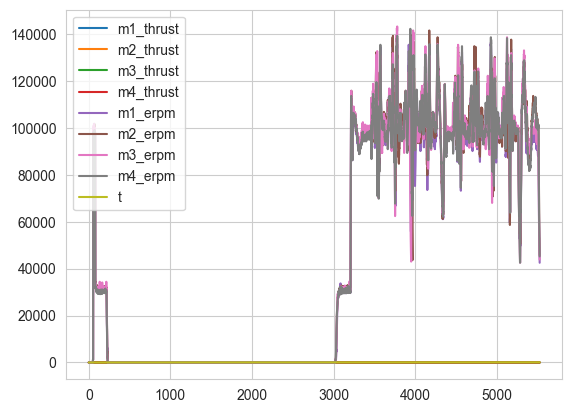

In [6]:
plt.figure()
(extract_dfs['/cf/motors']).plot()

# Time synchronization

In [7]:
import numpy as np
import pandas as pd
from scipy.signal import correlate
import matplotlib.pyplot as plt

def retime_wifi_topics(extract_dfs: dict, wifi_topics: dict, metadata_topic: str) -> dict:
    """
    Retime Wi-Fi topics using hardware timestamps from image_metadata.
    ROS timestamps are unreliable due to variable network latency.

    Parameters
    ----------
    extract_dfs : dict[str, pd.DataFrame]
        Extracted topic DataFrames, each containing at least a 't' column (ROS time).
    wifi_topics : dict[str, str]
        Mapping from topic -> field name in metadata containing hardware timestamp.
    metadata_topic : str
        Topic key in extract_dfs containing image metadata.

    Returns
    -------
    dict[str, pd.DataFrame]
        Updated extract_dfs with retimed Wi-Fi topics.
    """
    metadata_df = extract_dfs[metadata_topic]

    for topic, timestamp_field in wifi_topics.items():
        data_df = extract_dfs[topic].copy()

        # Filter out zero or invalid hardware timestamps
        valid_meta = metadata_df[metadata_df[timestamp_field] != 0].copy()
        if valid_meta.empty or data_df.empty:
            print(f"[WARN] Skipping {topic}: no valid metadata or empty data.")
            continue

        # Match messages by nearest ROS timestamp
        merged = pd.merge_asof(
            data_df.sort_values("t"),
            valid_meta.sort_values("t"),
            on="t",
            direction="nearest"
        )

        # Replace ROS timestamp with hardware timestamp (µs → ms → s)
        hw_timestamp = merged[timestamp_field] / 1e3
        data_df["ros_timestamp"] = data_df["t"]
        data_df["t"] = hw_timestamp

        # Drop duplicated timestamps (can happen if multiple messages share a hw time)
        data_df = data_df.drop_duplicates(subset="t")

        extract_dfs[topic] = data_df

    return extract_dfs


def estimate_clock_delays(
    extract_dfs: dict,
    latency_ref_base: str,
    latency_ref_fields: list[str],
    latency_ref_topic: dict,
    fs: float = 100.0,
    plot: bool = True
) -> dict:
    """
    Estimate relative clock delays between sources via multi-dimensional cross-correlation
    of position-, velocity-, or acceleration-like signals.

    Parameters
    ----------
    extract_dfs : dict[str, pd.DataFrame]
        Topic DataFrames, each with time column 't' and numeric signal columns.
    latency_ref_base : str
        Reference topic (e.g., mocap ground truth).
    latency_ref_fields : list[str]
        List of signal columns to use (e.g. ['x', 'y', 'z'] or ['vx', 'vy', 'vz']).
    latency_ref_topic : dict[str, str]
        Mapping from source name ('wifi', 'radio', etc.) → topic name.
    fs : float, optional
        Resampling frequency in Hz for uniform interpolation (default: 100).
    plot : bool, optional
        Whether to generate diagnostic plots.

    Returns
    -------
    dict[str, float]
        Estimated clock delay (seconds) for each source.
    """
    ref_df = extract_dfs[latency_ref_base].set_index("t")
    available_fields = [f for f in latency_ref_fields if f in ref_df.columns]
    if not available_fields:
        raise ValueError(f"No valid reference fields found in {latency_ref_base}")
    ref_data = ref_df[available_fields].to_numpy()
    clock_delays = {}

    if plot:
        fig, axs = plt.subplots(len(latency_ref_topic), 1, figsize=(8, 10))

    for i, (source, topic) in enumerate(latency_ref_topic.items()):
        meas_df = extract_dfs[topic].set_index("t")
        fields = [f for f in latency_ref_fields if f in meas_df.columns]
        if not fields:
            print(f"[WARN] Skipping {topic}: missing fields {latency_ref_fields}")
            continue

        meas_data = meas_df[fields].to_numpy()

        # Common uniform time base (union of both)
        t_min = min(ref_df.index[0], meas_df.index[0])
        t_max = max(ref_df.index[-1], meas_df.index[-1])
        t_uniform = np.arange(t_min, t_max, 1 / fs)

        # Interpolate each dimension
        ref_interp = np.vstack([
            np.interp(t_uniform, ref_df.index, ref_df[col],
                      left=ref_df[col].iloc[0], right=ref_df[col].iloc[-1])
            for col in available_fields
        ]).T
        meas_interp = np.vstack([
            np.interp(t_uniform, meas_df.index, meas_df[col],
                      left=meas_df[col].iloc[0], right=meas_df[col].iloc[-1])
            for col in fields
        ]).T

        # Normalize per dimension
        ref_norm = (ref_interp - np.mean(ref_interp, axis=0)) / np.std(ref_interp, axis=0)
        meas_norm = (meas_interp - np.mean(meas_interp, axis=0)) / np.std(meas_interp, axis=0)

        # Combined cross-correlation (sum over dimensions)
        corr_sum = np.zeros(len(ref_norm) * 2 - 1)
        for j in range(ref_norm.shape[1]):
            corr_sum += correlate(meas_norm[:, j], ref_norm[:, j], mode="full")

        lags = np.arange(-len(ref_norm) + 1, len(meas_norm))
        delay_samples = lags[np.argmax(corr_sum)]
        delay_seconds = delay_samples / fs
        clock_delays[source] = delay_seconds

        # --- Plotting ---
        if plot:
            ax = axs[i] if len(latency_ref_topic) > 1 else axs
            # Plot a representative dimension (first one)
            ax.plot(t_uniform, ref_norm[:, 0], label="Reference")
            ax.plot(t_uniform, meas_norm[:, 0], label="Measured", alpha=0.7)
            ax.plot(t_uniform - delay_seconds, meas_norm[:, 0],
                    label="Aligned", alpha=0.8)
            ax.set_title(f"{source}: Δt = {delay_seconds:+.3f} s")
            ax.legend()
            ax.grid(True, linestyle="--", alpha=0.4)

            ax2 = ax.twinx()
            ax2.plot(lags / fs, corr_sum, "r", alpha=0.3)
            ax2.set_ylabel("Combined Cross-correlation")

    if plot:
        fig.suptitle("Multi-dimensional Clock Delay Estimation", fontsize=12)
        fig.tight_layout()

    print("\nEstimated clock delays (seconds):")
    for src, delay in clock_delays.items():
        print(f"  {src:<8}: {delay:+.3f} s")

    return clock_delays

def apply_clock_delays(extract_dfs: dict, topic_sources: dict, clock_delays: dict) -> dict:
    """
    Apply estimated clock delays to each topic's timestamps.

    Parameters
    ----------
    extract_dfs : dict[str, pd.DataFrame]
        Topic DataFrames containing a 't' column.
    topic_sources : dict[str, str]
        Mapping from topic name -> source type ('mocap', 'wifi', 'radio', ...).
    clock_delays : dict[str, float]
        Estimated clock delays in seconds for each source.
        Positive = source lags behind mocap.

    Returns
    -------
    dict[str, pd.DataFrame]
        Updated topic DataFrames with corrected timestamps.
    """
    for topic, source in topic_sources.items():
        if topic not in extract_dfs or extract_dfs[topic].empty:
            print(f"[WARN] Skipping {topic}: missing or empty DataFrame.")
            continue

        if source not in clock_delays:
            print(f"[WARN] No clock delay defined for source '{source}' (topic {topic}).")
            continue

        delay = clock_delays[source]
        extract_dfs[topic]['t'] -= delay
        print(f"{topic:20s}: shifted by {delay:+.3f} s ({source})")

    return extract_dfs




Estimated clock delays (seconds):
  mocap   : +0.000 s
  radio   : -0.140 s
  wifi    : +24.930 s
/poses              : shifted by +0.000 s (mocap)
/cf/pose            : shifted by -0.140 s (radio)
/cf/status          : shifted by -0.140 s (radio)
/cf/control_radio   : shifted by -0.140 s (radio)
/cf/image_metadata  : shifted by +24.930 s (wifi)
/cf/image_odom      : shifted by +24.930 s (wifi)
/cf/image_accel     : shifted by +24.930 s (wifi)
/cf/motors          : shifted by +24.930 s (wifi)
/cf/setpoint        : shifted by +24.930 s (wifi)


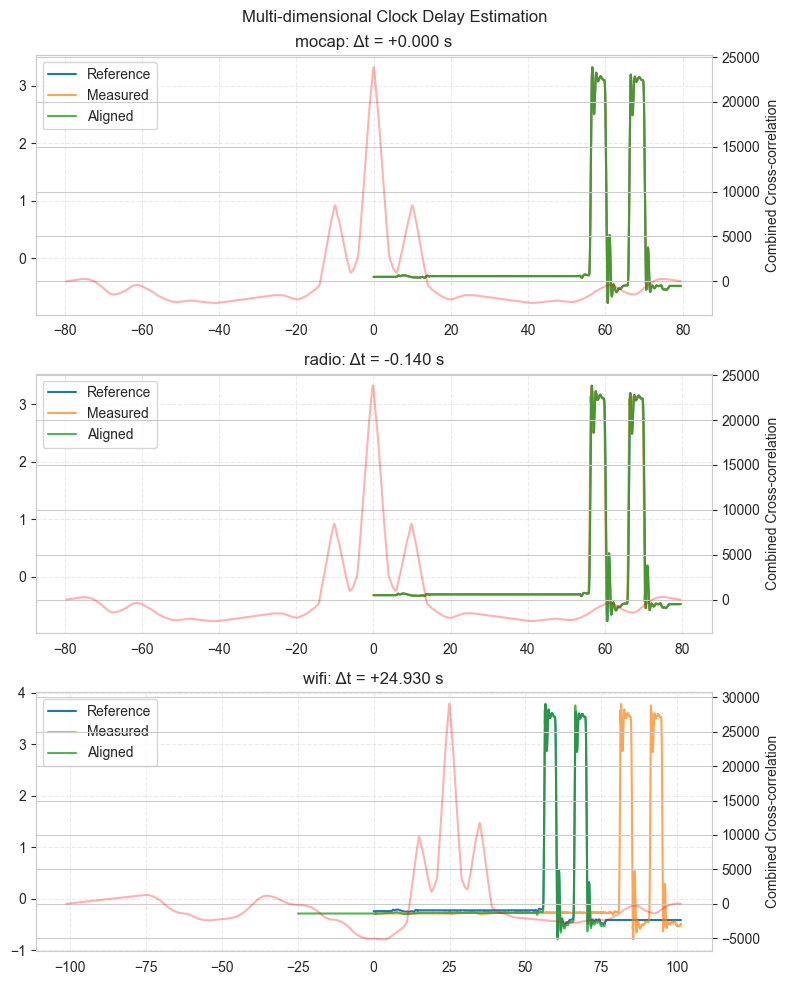

In [8]:
wifi_topics = {
    '/cf/image_odom': 'state_stm32_timestamp',
    '/cf/image_accel': 'state_stm32_timestamp',
    '/cf/motors': 'state_stm32_timestamp',
    '/cf/setpoint': 'setpoint_stm32_timestamp',
}
metadata_topic = '/cf/image_metadata'

extract_dfs = retime_wifi_topics(extract_dfs, wifi_topics, metadata_topic)
clock_delays = estimate_clock_delays(
    extract_dfs=extract_dfs,
    latency_ref_base='/poses',
    latency_ref_fields=['x', 'y', 'z'],  # or ['vx', 'vy', 'vz'], or ['ax', 'ay', 'az']
    latency_ref_topic={
        'mocap': '/poses',
        'radio': '/cf/pose',
        'wifi':  '/cf/image_odom',
    },
    fs=100.0,
    plot=True
)

# Example source mapping
topic_sources = {
    '/poses': 'mocap',
    '/cf/pose': 'radio',
    '/cf/status': 'radio',
    '/cf/control_radio': 'radio',
    '/cf/image_metadata': 'wifi',
    '/cf/image_odom': 'wifi',
    '/cf/image_accel': 'wifi',
    '/cf/motors': 'wifi',
    '/cf/setpoint': 'wifi',
}

# Apply clock alignment
extract_dfs = apply_clock_delays(extract_dfs, topic_sources, clock_delays)

# Final

Here I compare the recorded data from the different data sources:
- State estimation streamed over Wi-Fi - all components (pos, vel, orient, ang. vel) but has occasional packet drops
- State estimation streamed over radio - pos only, but more reliable
- Motion capture - pos only

- Setpoints streamed over Wi-Fi - pos and vel only, the rest are controlled reactively by the onboard PIDs

In [9]:
state_wifi_df = extract_dfs['/cf/image_odom']
state_radio_df = extract_dfs['/cf/pose']
mocap_df = extract_dfs['/poses']
setpoint_df = extract_dfs['/cf/setpoint']

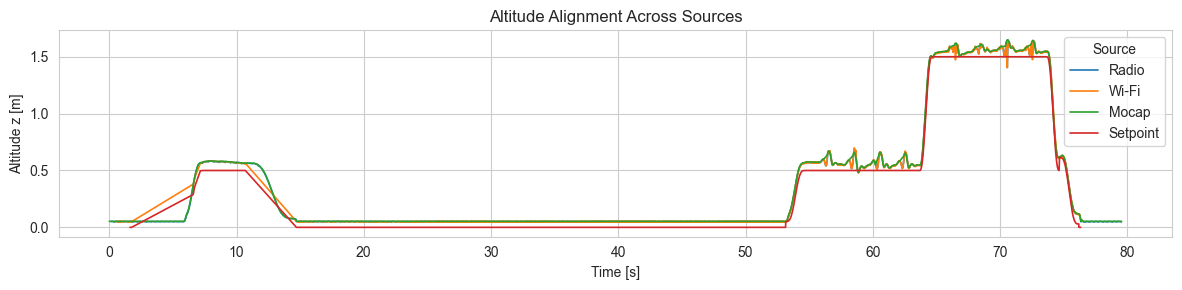

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 3))

sns.lineplot(data=state_radio_df,  x='t', y='z', label="Radio", linewidth=1.2)
sns.lineplot(data=state_wifi_df,   x='t', y='z', label="Wi-Fi", linewidth=1.2)
sns.lineplot(data=mocap_df,        x='t', y='z', label="Mocap", linewidth=1.2)
sns.lineplot(data=setpoint_df,     x='t', y='z', label="Setpoint", linewidth=1.2)

plt.xlabel("Time [s]")
plt.ylabel("Altitude z [m]")
plt.title("Altitude Alignment Across Sources")
plt.legend(title="Source")
plt.tight_layout()
plt.show()


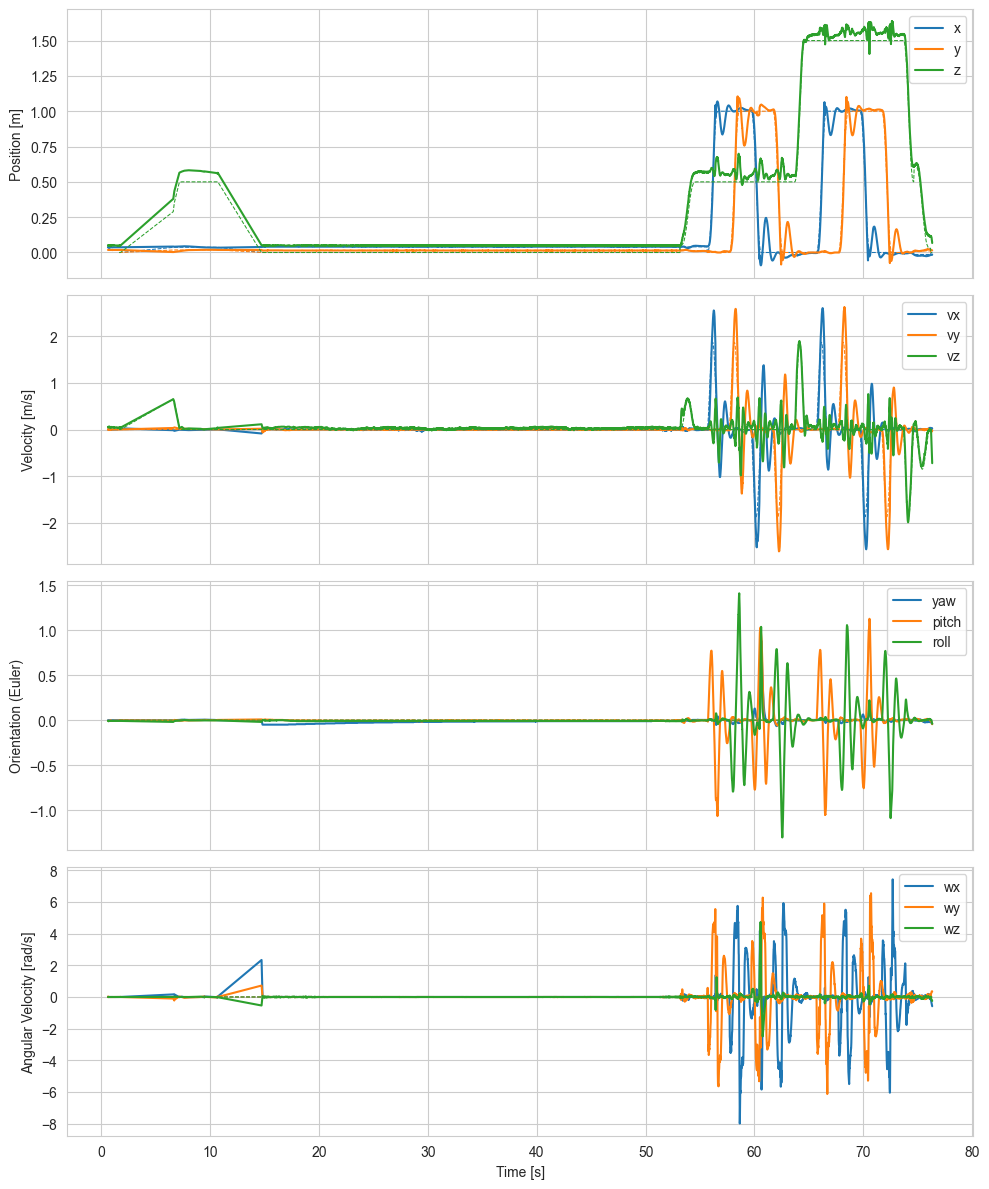

In [11]:
plot_state_grid(state_wifi_df, setpoint_df, orient='euler');

In [12]:
import pandas as pd

def get_flight_window(extract_dfs: dict, status_topic: str = '/cf/status') -> tuple[float, float]:
    """
    Determine the time interval when the drone is flying.

    Parameters
    ----------
    extract_dfs : dict[str, pd.DataFrame]
        Dictionary of topic DataFrames.
    status_topic : str, optional
        Topic containing the 'is_flying' boolean flag.

    Returns
    -------
    (t_min, t_max) : tuple[float, float]
        Start and end timestamps (seconds) of the flight interval.
    """
    status_df = extract_dfs[status_topic]
    if 'is_flying' not in status_df.columns:
        raise ValueError(f"{status_topic} has no 'is_flying' column.")

    flying_mask = status_df['is_flying'].astype(bool)
    flying_times = status_df.loc[flying_mask, 't']

    if flying_times.empty:
        raise ValueError("No flying interval detected.")

    t_min, t_max = flying_times.min(), flying_times.max()
    print(f"Detected flight window: {t_min:.2f} → {t_max:.2f} s")
    return t_min, t_max


def crop_topics_to_flight(extract_dfs: dict, t_min: float, t_max: float, topics: list[str]) -> dict:
    """
    Restrict each DataFrame to the flying interval.

    Parameters
    ----------
    extract_dfs : dict[str, pd.DataFrame]
        Topic DataFrames with a 't' column.
    t_min, t_max : float
        Flight window (seconds).
    topics : list[str]
        Topics to crop.

    Returns
    -------
    dict[str, pd.DataFrame]
        Updated topic DataFrames.
    """
    for topic in topics:
        df = extract_dfs.get(topic)
        if df is None or 't' not in df.columns:
            print(f"[WARN] Skipping {topic}: missing or invalid DataFrame.")
            continue
        cropped = df[(df['t'] >= t_min) & (df['t'] <= t_max)].copy()
        extract_dfs[topic] = cropped.sort_values('t').reset_index(drop=True)
        print(f"{topic}: kept {len(cropped)} samples.")
    return extract_dfs


def merge_topics(
    extract_dfs: dict,
    base_topic: str = '/cf/image_odom',
    merge_order: list[str] = None
) -> pd.DataFrame:
    """
    Merge multiple topic DataFrames on their timestamps using nearest-neighbor alignment.

    Parameters
    ----------
    extract_dfs : dict[str, pd.DataFrame]
        Dictionary of topic DataFrames.
    base_topic : str, optional
        Topic used as reference timeline.
    merge_order : list[str], optional
        Topics to merge sequentially. If None, merges all except the base.

    Returns
    -------
    merged_df : pd.DataFrame
        Combined DataFrame with aligned signals.
    """
    if merge_order is None:
        merge_order = [k for k in extract_dfs.keys() if k != base_topic]

    merged_df = extract_dfs[base_topic].sort_values('t').copy()
    print(f"Starting merge from base topic: {base_topic}")

    for topic in merge_order:
        df = extract_dfs.get(topic)
        if df is None or 't' not in df.columns:
            print(f"[WARN] Skipping {topic}: missing or invalid DataFrame.")
            continue

        suffix = f"_{topic.split('/')[-1]}"  # add topic-based suffix
        merged_df = pd.merge_asof(
            merged_df.sort_values('t'),
            df.sort_values('t'),
            on='t',
            direction='nearest',
            suffixes=('', suffix)
        )
        print(f"  merged: {topic} ({len(df)} samples)")

    # Normalize time to start at zero
    merged_df['t'] -= merged_df['t'].iloc[0]
    # Example axis correction (specific to Crazyflie convention)
    if 'wy' in merged_df.columns:
        merged_df['wy'] = -merged_df['wy']

    print(f"\nMerged DataFrame shape: {merged_df.shape}")
    return merged_df

In [54]:
# 1️⃣ Detect flying window
t_min, t_max = get_flight_window(extract_dfs, status_topic='/cf/status')

# 2️⃣ Crop all topics to that interval
topics_to_crop = [
    '/poses', '/cf/motors', '/cf/image_odom', '/cf/image_accel',
    '/cf/setpoint', '/cf/status', '/cf/control_radio'
]
extract_dfs = crop_topics_to_flight(extract_dfs, t_min, t_max, topics_to_crop)

# 3️⃣ Merge aligned topics
merge_order = [
    '/poses', '/cf/motors', '/cf/control_radio',
    '/cf/image_accel', '/cf/setpoint', '/cf/status'
]
merged_df = merge_topics(extract_dfs, base_topic='/cf/image_odom', merge_order=merge_order)

Detected flight window: 5.90 → 78.16 s
/poses: kept 6969 samples.
/cf/motors: kept 4993 samples.
/cf/image_odom: kept 5314 samples.
/cf/image_accel: kept 5314 samples.
/cf/setpoint: kept 1331 samples.
/cf/status: kept 1808 samples.
/cf/control_radio: kept 7228 samples.
Starting merge from base topic: /cf/image_odom
  merged: /poses (6969 samples)
  merged: /cf/motors (4993 samples)
  merged: /cf/control_radio (7228 samples)
  merged: /cf/image_accel (5314 samples)
  merged: /cf/setpoint (1331 samples)
  merged: /cf/status (1808 samples)

Merged DataFrame shape: (5314, 70)


In [55]:
t_min = merged_df['t'].min()
t_max = merged_df['t'].max()

# Generate uniformly spaced time vector at 100 Hz (i.e. every 0.01s)
t_uniform = np.arange(t_min, t_max, 0.01)

resampled_df = merged_df.set_index('t').reindex(t_uniform, method="nearest").reset_index()
resampled_df.rename(columns={'index': 't'}, inplace=True)

In [56]:
resampled_df.to_csv(os.path.join('../data/real/raw/csv', experiment_name + f"_run{run}" + '.csv'))